## Data

### cBioPortal

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
project_folder = 'drive/MyDrive/AI_Gene/ai_gene_project'
os.chdir(project_folder)
os.listdir()

In [ ]:
pip install cbio-py

In [ ]:
import pandas as pd
from cbio_py import cbio_mod as cb
from tqdm.notebook import tqdm

STUDY_ID = "msk_impact_50k_2026"
MOLECULAR_PROFILE_ID = f"{STUDY_ID}_mutations"
SAMPLE_LIST_ID = f"{STUDY_ID}_all"

client = cb.cbioportal

print("Fetching the systematic MSK-IMPACT 505 gene list...")
# Get the exact panel used for the latest MSK sequencing
panel = client.Gene_Panels.getGenePanelUsingGET(genePanelId="IMPACT505").result()

# Dynamically build your TARGET_GENES dictionary mapping Hugo -> Entrez ID
TARGET_GENES = {gene.hugoGeneSymbol: gene.entrezGeneId for gene in panel.genes}

print(f"Successfully loaded {len(TARGET_GENES)} genes systematically!")

MAX_MUTATIONS_PER_GENE = 500

def extract_targeted_mutations():
    print(f"Fetching mutations for cohort: {STUDY_ID}...\n")
    all_filtered_mutations = []

    # We access the underlying Bravado Swagger client exposed by cbio_py.
    # This allows us to pass the required `entrezGeneId` parameter explicitly.
    client = cb.cbioportal

    for hugo_symbol, entrez_id in tqdm(TARGET_GENES.items()):
        # print(f"Querying {hugo_symbol} (Entrez ID: {entrez_id})...")

        try:
            # This calls the exact endpoint that was throwing your 400 error,
            # but now correctly supplies the required gene ID to keep the payload small.
            response = client.Mutations.getMutationsInMolecularProfileBySampleListIdUsingGET(
                molecularProfileId=MOLECULAR_PROFILE_ID,
                sampleListId=SAMPLE_LIST_ID,
                entrezGeneId=entrez_id,
                projection="DETAILED"
            ).result()

            # Extract the data from the Bravado response models
            count = 0
            for mut_model in response:
                if count >= MAX_MUTATIONS_PER_GENE:
                    break

                # Unpack the specific attributes we care about into a clean dictionary
                mut_dict = {
                    "sampleId": getattr(mut_model, "sampleId", None),
                    "hugoGeneSymbol": hugo_symbol,
                    "mutationType": getattr(mut_model, "mutationType", None),
                    "proteinChange": getattr(mut_model, "proteinChange", None),
                    "entrezGeneId": entrez_id
                }
                all_filtered_mutations.append(mut_dict)
                count += 1

        except Exception as e:
            print(f"  [!] Failed to fetch {hugo_symbol}: {e}")

    return pd.DataFrame(all_filtered_mutations)

if __name__ == "__main__":
    df_mutations = extract_targeted_mutations()

    print(f"\nExtraction complete. Found {len(df_mutations)} mutations.")
    if not df_mutations.empty:
        print(df_mutations)

Fetching the systematic MSK-IMPACT 505 gene list...
Successfully loaded 505 genes systematically!
Fetching mutations for cohort: msk_impact_50k_2026...



  0%|          | 0/505 [00:00<?, ?it/s]


Extraction complete. Found 191464 mutations.
                 sampleId hugoGeneSymbol       mutationType proteinChange  \
0       P-0000039-T01-IM3           ABL1  Missense_Mutation         C369Y   
1       P-0000315-T01-IM3           ABL1  Missense_Mutation         E581Q   
2       P-0000377-T02-IM3           ABL1  Missense_Mutation         G839S   
3       P-0000475-T01-IM3           ABL1  Missense_Mutation         R328K   
4       P-0000507-T01-IM3           ABL1    Frame_Shift_Del   K947Sfs*122   
...                   ...            ...                ...           ...   
191459  P-0067930-T01-IM7          ZRSR2  Missense_Mutation         L297P   
191460  P-0067968-T02-IM7          ZRSR2  Missense_Mutation         R446Q   
191461  P-0068191-T01-IM7          ZRSR2  Missense_Mutation          R99W   
191462  P-0068638-T01-IM7          ZRSR2        Splice_Site   X186_splice   
191463  P-0069654-T01-IM7          ZRSR2       In_Frame_Del  S445_R448del   

        entrezGeneId  
0     

In [ ]:
# import pandas as pd

# # Define the columns before calling them!
# cols_to_keep = [
#     'GeneSymbol',
#     'Name',
#     'Type',
#     'Assembly',
#     'Oncogenicity',
#     'ReviewStatusOncogenicity'
# ]

# print("Downloading and parsing ClinVar variant summary (Colab will do this fast!)...")

# # Direct link to the NIH server
# clinvar_url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz"

# # Download and parse directly into RAM
# df_clinvar = pd.read_csv(
#     clinvar_url,
#     sep='\t',
#     compression='gzip',
#     usecols=cols_to_keep,
#     low_memory=False
# )

# print(f"Success! Loaded {len(df_clinvar)} rows.")

# # Use 'display' instead of 'print' in Colab to get a beautiful, interactive table
# display(df_clinvar.head())

# # 2. Filter for the right data types
# df_clinvar = df_clinvar[df_clinvar['Assembly'] == 'GRCh38']
# df_clinvar = df_clinvar[df_clinvar['Type'] == 'single nucleotide variant']

# # 3. Extract the Protein Change from the "Name" column
# # This looks for the parentheses containing 'p.' and extracts what's inside
# df_clinvar['protein_change'] = df_clinvar['Name'].str.extract(r'\(p\.(.*?)\)')

# # 4. Clean up the Oncogenicity Label for ML (1 = Oncogenic, 0 = Benign)
# def make_ml_label(val):
#     val_str = str(val).lower()
#     if 'oncogenic' in val_str and 'benign' not in val_str:
#         return 1
#     elif 'benign' in val_str and 'oncogenic' not in val_str:
#         return 0
#     else:
#         return None # Drops VUS (Variants of Unknown Significance) and nulls

# df_clinvar['ML_Label'] = df_clinvar['Oncogenicity'].apply(make_ml_label)

# # Drop any rows that didn't get a clean 1 or 0
# df_clinvar = df_clinvar.dropna(subset=['ML_Label', 'protein_change'])

# print(df_clinvar[['GeneSymbol', 'protein_change', 'Oncogenicity', 'ML_Label']].head())

In [ ]:
import pandas as pd
import requests
from tqdm.notebook import tqdm  # This makes the progress bar look great in Colab

url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz"
filename = "variant_summary.txt.gz"

print("Starting download...")

# 1. Download the file with a progress bar
response = requests.get(url, stream=True)
total_size = int(response.headers.get('content-length', 0))

with open(filename, 'wb') as file, tqdm(
    desc="Downloading ClinVar",
    total=total_size,
    unit='iB',
    unit_scale=True,
    unit_divisor=1024,
) as bar:
    for data in response.iter_content(chunk_size=1024):
        size = file.write(data)
        bar.update(size)

print("\nDownload complete! Now parsing into Pandas...")

Starting download...



Download complete! Now parsing into Pandas...


In [ ]:

# 2. Define the columns we want to keep
cols_to_keep = [
    'GeneSymbol',
    'Name',
    'Type',
    'Assembly',
    'Oncogenicity',
    'ReviewStatusOncogenicity',
    'ClinicalSignificance'
]

# 3. Read the locally downloaded file
df_clinvar_raw = pd.read_csv(
    filename,
    sep='\t',
    compression='gzip',
    usecols=cols_to_keep,
    low_memory=False
)

print(f"Success! Loaded {len(df_clinvar_raw)} rows.")
display(df_clinvar_raw.head())

Success! Loaded 8918806 rows.


,Type,Name,GeneSymbol,ClinicalSignificance,Assembly,Oncogenicity,ReviewStatusOncogenicity
0,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,AP5Z1,Pathogenic/Likely pathogenic,GRCh37,-,-
1,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,AP5Z1,Pathogenic/Likely pathogenic,GRCh38,-,-
2,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),AP5Z1,Pathogenic,GRCh37,-,-
3,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),AP5Z1,Pathogenic,GRCh38,-,-
4,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),ZNF592,Uncertain significance,GRCh37,-,-


In [ ]:
df_clinvar = df_clinvar_raw

In [ ]:
df_clinvar.columns

Index(['Type', 'Name', 'GeneSymbol', 'ClinicalSignificance', 'Assembly',
       'Oncogenicity', 'ReviewStatusOncogenicity'],
      dtype='object')

In [ ]:

# 2. Filter for the right data types
df_clinvar = df_clinvar[df_clinvar['Assembly'] == 'GRCh38']
df_clinvar = df_clinvar[df_clinvar['Type'] == 'single nucleotide variant']

# 3. Extract the Protein Change from the "Name" column
# This looks for the parentheses containing 'p.' and extracts what's inside
df_clinvar['protein_change'] = df_clinvar['Name'].str.extract(r'\(p\.(.*?)\)')

# # 4. Clean up the Oncogenicity Label for ML (1 = Oncogenic, 0 = Benign)
# def make_ml_label(val):
#     val_str = str(val).lower()
#     if 'oncogenic' in val_str and 'benign' not in val_str:
#         return 1
#     elif 'benign' in val_str and 'oncogenic' not in val_str:
#         return 0
#     else:
#         return None # Drops VUS (Variants of Unknown Significance) and nulls

# df_clinvar['ML_Label'] = df_clinvar['Oncogenicity'].apply(make_ml_label)

# # Drop any rows that didn't get a clean 1 or 0
# df_clinvar = df_clinvar.dropna(subset=['ML_Label', 'protein_change'])

# print(df_clinvar[['GeneSymbol', 'protein_change', 'Oncogenicity', 'ML_Label']].head())
# 4. Clean up the Label using a Fallback strategy
def make_ml_label(row):
    # Try the specific Oncogenicity column first
    onco_str = str(row['Oncogenicity']).lower()
    if 'oncogenic' in onco_str and 'benign' not in onco_str:
        return 1
    elif 'benign' in onco_str and 'oncogenic' not in onco_str:
        return 0

    # If Oncogenicity is empty/unhelpful, fall back to ClinicalSignificance
    clin_str = str(row['ClinicalSignificance']).lower()

    # We must exclude 'conflicting' to keep our ground truth pure
    if 'conflicting' in clin_str:
        return None

    if 'pathogenic' in clin_str:
        return 1
    elif 'benign' in clin_str:
        return 0

    # If neither column has a clean driver/passenger label, drop it
    return None

# Notice we use axis=1 so the function can access the whole row at once
df_clinvar['ML_Label'] = df_clinvar.apply(make_ml_label, axis=1)

# Drop any rows that didn't get a clean 1 or 0
df_clinvar = df_clinvar.dropna(subset=['ML_Label', 'protein_change'])

print(f"Total usable ML training variants: {len(df_clinvar)}")

Total usable ML training variants: 965894


In [ ]:
df_clinvar.shape

(965894, 9)

In [ ]:
df_mutations.columns

Index(['sampleId', 'hugoGeneSymbol', 'mutationType', 'proteinChange',
       'entrezGeneId'],
      dtype='object')

In [ ]:
df_clinvar.columns

Index(['Type', 'Name', 'GeneSymbol', 'ClinicalSignificance', 'Assembly',
       'Oncogenicity', 'ReviewStatusOncogenicity', 'protein_change',
       'ML_Label'],
      dtype='object')

In [ ]:
import pandas as pd

# 1. Dictionary to translate 3-letter amino acid codes to 1-letter codes
aa_map = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Glu': 'E', 'Gln': 'Q', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', '=': '='  # 'Ter' or '*' represent stop codons
}

def translate_to_1_letter(protein_str):
    if pd.isna(protein_str):
        return protein_str

    # Replace every 3-letter code found in the string with its 1-letter equivalent
    converted = str(protein_str)
    for three_letter, one_letter in aa_map.items():
        converted = converted.replace(three_letter, one_letter)
    return converted

print("Prepping tables for merge...")

# 2. Clean the cBioPortal table (df_mutations)
# Strip the "p." prefix just in case it's there
df_mutations['proteinChange_clean'] = df_mutations['proteinChange'].str.replace('p.', '', regex=False)

# 3. Clean and translate the ClinVar table (df_clinvar)
df_clinvar['protein_change_clean'] = df_clinvar['protein_change'].apply(translate_to_1_letter)

# 4. THE MERGE
# We use an 'inner' join, which means it will ONLY keep the rows where
# both the Gene AND the Protein Change match perfectly in both tables.
df_merged = pd.merge(
    left=df_mutations,
    right=df_clinvar,
    left_on=['hugoGeneSymbol', 'proteinChange_clean'],
    right_on=['GeneSymbol', 'protein_change_clean'],
    how='inner'
)

# 5. Display the results!
print("--- MERGE COMPLETE ---")
print(f"Original cBioPortal mutations: {len(df_mutations)}")
print(f"Valid mutations successfully mapped to an ML Label: {len(df_merged)}")

# Optional: Drop the redundant merge columns to keep your dataframe clean
columns_to_drop = ['GeneSymbol', 'protein_change_clean', 'proteinChange_clean']
df_final = df_merged.drop(columns=columns_to_drop, errors='ignore')

# Show the final beautiful dataset ready for your AI model
if not df_final.empty:
    display(df_final[['sampleId', 'hugoGeneSymbol', 'proteinChange', 'Oncogenicity', 'ML_Label']].head(10))

Prepping tables for merge...
--- MERGE COMPLETE ---
Original cBioPortal mutations: 191464
Valid mutations successfully mapped to an ML Label: 15108


,sampleId,hugoGeneSymbol,proteinChange,Oncogenicity,ML_Label
0,P-0000764-T01-IM3,ABL1,A969T,-,0.0
1,P-0001453-T01-IM3,ABL1,T204M,-,0.0
2,P-0001475-T01-IM3,ABL1,G626S,-,0.0
3,P-0002124-T01-IM3,ABL1,E509K,-,1.0
4,P-0004154-T01-IM5,ABL1,G254R,-,1.0
5,P-0004691-T02-IM5,ABL1,T743M,-,0.0
6,P-0004738-T01-IM5,ABL1,R589H,-,0.0
7,P-0004888-T01-IM5,ABL1,R738Q,-,0.0
8,P-0006717-T01-IM5,ABL1,S915L,-,0.0
9,P-0007076-T03-IM5,ABL1,S977N,-,0.0


In [ ]:
df_clinvar['Oncogenicity'].unique()

array(['-', 'Likely oncogenic', 'Oncogenic', 'Benign',
       'Uncertain significance', 'Likely benign',
       'Conflicting classifications of oncogenicity'], dtype=object)

In [ ]:
df_final['Oncogenicity'].unique()

array(['-', 'Uncertain significance', 'Oncogenic', 'Likely oncogenic',
       'Conflicting classifications of oncogenicity'], dtype=object)

In [ ]:
df_final['proteinChange'].unique()

array(['A969T', 'T204M', 'G626S', ..., 'C319Y', 'C296Y', 'R295*'],
      dtype=object)

In [ ]:
df_final['hugoGeneSymbol'].unique()

array(['ABL1', 'ACVR1', 'AGO2', 'AKT1', 'AKT2', 'AKT3', 'ALB', 'ALK',
       'ALOX12B', 'AMER1', 'ANKRD11', 'APC', 'AR', 'ARHGAP35', 'ARID1A',
       'ARID1B', 'ARID2', 'ARID5B', 'ASXL1', 'ASXL2', 'ATM', 'ATR',
       'ATRX', 'ATXN7', 'AURKA', 'AURKB', 'AXIN1', 'AXIN2', 'AXL', 'B2M',
       'BAP1', 'BARD1', 'BCL10', 'BCL6', 'BCOR', 'BIRC3', 'BLM', 'BMPR1A',
       'BRAF', 'BRCA1', 'BRCA2', 'BRD4', 'BRIP1', 'BTK', 'CALR', 'CARD11',
       'CARM1', 'CBL', 'CCND1', 'CCND2', 'CCNE1', 'CD274', 'CD276',
       'CDC42', 'CDC73', 'CDH1', 'CDK12', 'CDK4', 'CDK6', 'CDK8',
       'CDKN1A', 'CDKN1B', 'CDKN2A', 'CDKN2C', 'CEBPA', 'CENPA', 'CHEK2',
       'CREBBP', 'CSF1R', 'CSF3R', 'CTCF', 'CTLA4', 'CTNNB1', 'CTR9',
       'CUL3', 'CXCR4', 'CYLD', 'CYP19A1', 'CYSLTR2', 'DAXX', 'DDR2',
       'DICER1', 'DIS3', 'DNMT1', 'DNMT3A', 'DNMT3B', 'DOT1L', 'DROSHA',
       'DUSP4', 'EED', 'EGFL7', 'EGFR', 'EIF1AX', 'EIF4A2', 'EP300',
       'EPAS1', 'EPCAM', 'EPHA5', 'ERBB2', 'ERBB3', 'ERBB4', 'ERCC2',
     

In [ ]:
df_clinvar.shape

(965894, 10)

In [ ]:
df_clinvar['GeneSymbol'].unique()

array(['FOXRED1', 'HFE', 'WDR35', ..., 'GINS3', 'LOC129998021;TWIST1',
       'PPTC7'], dtype=object)

In [ ]:
df_mutations['hugoGeneSymbol'].unique()

array(['ABL1', 'ABRAXAS1', 'ACVR1', 'AGO2', 'AKT1', 'AKT2', 'AKT3', 'ALB',
       'ALK', 'ALOX12B', 'AMER1', 'ANKRD11', 'APC', 'APLNR', 'AR', 'ARAF',
       'ARHGAP35', 'ARID1A', 'ARID1B', 'ARID2', 'ARID5B', 'ASXL1',
       'ASXL2', 'ATM', 'ATR', 'ATRX', 'ATXN7', 'AURKA', 'AURKB', 'AXIN1',
       'AXIN2', 'AXL', 'B2M', 'BABAM1', 'BAP1', 'BARD1', 'BBC3', 'BCL10',
       'BCL2', 'BCL2L1', 'BCL2L11', 'BCL6', 'BCOR', 'BIRC3', 'BLM',
       'BMPR1A', 'BRAF', 'BRCA1', 'BRCA2', 'BRD4', 'BRIP1', 'BTK', 'CALR',
       'CARD11', 'CARM1', 'CASP8', 'CBFB', 'CBL', 'CCND1', 'CCND2',
       'CCND3', 'CCNE1', 'CCNQ', 'CD274', 'CD276', 'CD79A', 'CD79B',
       'CDC42', 'CDC73', 'CDH1', 'CDK12', 'CDK4', 'CDK6', 'CDK8',
       'CDKN1A', 'CDKN1B', 'CDKN2A', 'CDKN2B', 'CDKN2C', 'CEBPA', 'CENPA',
       'CHEK1', 'CHEK2', 'CIC', 'COP1', 'CREBBP', 'CRKL', 'CRLF2',
       'CSDE1', 'CSF1R', 'CSF3R', 'CTCF', 'CTLA4', 'CTNNB1', 'CTR9',
       'CUL3', 'CXCR4', 'CYLD', 'CYP19A1', 'CYSLTR2', 'DAXX', 'DCUN1D1',
     

In [ ]:
df_clinvar['GeneSymbol'].unique()

array(['FOXRED1', 'HFE', 'WDR35', ..., 'GINS3', 'LOC129998021;TWIST1',
       'PPTC7'], dtype=object)

In [ ]:
df_clinvar.columns

Index(['Type', 'Name', 'GeneSymbol', 'ClinicalSignificance', 'Assembly',
       'Oncogenicity', 'ReviewStatusOncogenicity', 'protein_change',
       'ML_Label', 'protein_change_clean'],
      dtype='object')

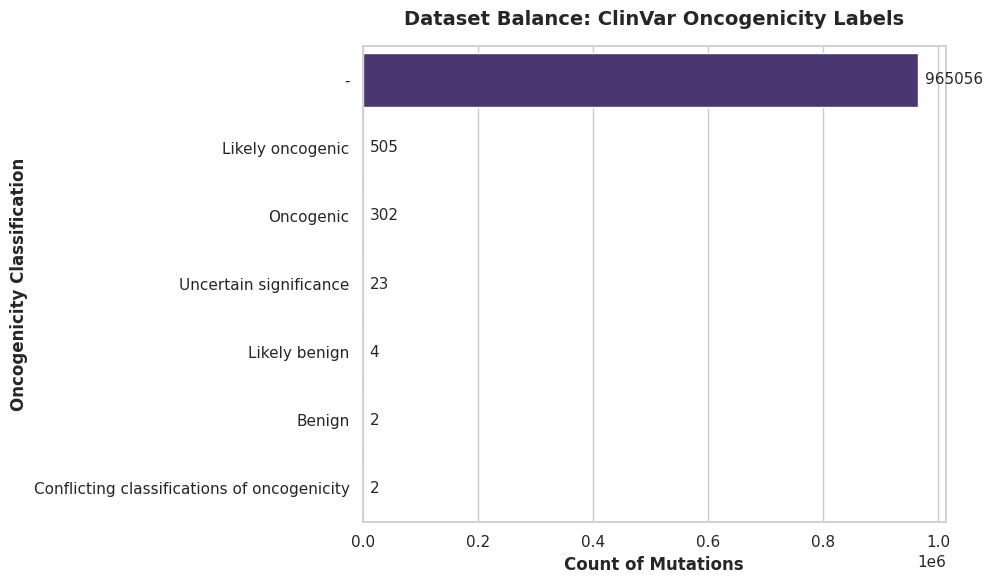

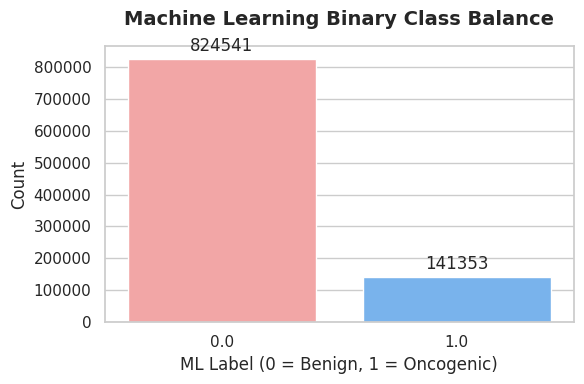

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plot
sns.set_theme(style="whitegrid")

# Create a figure with a good size for Colab
plt.figure(figsize=(10, 6))

# We use value_counts() to get the exact sorted order
label_counts = df_clinvar['Oncogenicity'].value_counts()

# Create a horizontal bar plot (y='Oncogenicity') so the long labels are readable
ax = sns.barplot(
    x=label_counts.values,
    y=label_counts.index,
    palette="viridis",
    hue=label_counts.index,
    legend=False
)

# Add titles and labels
plt.title('Dataset Balance: ClinVar Oncogenicity Labels', fontsize=14, weight='bold', pad=15)
plt.xlabel('Count of Mutations', fontsize=12, weight='bold')
plt.ylabel('Oncogenicity Classification', fontsize=12, weight='bold')

# Add the exact numbers to the end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fmt='%d', fontsize=11)

# Ensure everything fits perfectly without cutting off text
plt.tight_layout()

# Display the plot
plt.show()

# ---------------------------------------------------------
# OPTIONAL: Also plot the binary ML_Label (1 vs 0) balance
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
ax2 = sns.countplot(
    data=df_clinvar,
    x='ML_Label',
    palette=['#ff9999', '#66b3ff'], # Red for 0, Blue for 1
    hue='ML_Label',
    legend=False
)

plt.title('Machine Learning Binary Class Balance', fontsize=14, weight='bold', pad=15)
plt.xlabel('ML Label (0 = Benign, 1 = Oncogenic)', fontsize=12)
plt.ylabel('Count', fontsize=12)

for container in ax2.containers:
    ax2.bar_label(container, padding=3, fmt='%d')

plt.tight_layout()
plt.show()

In [ ]:
df_clinvar['ClinicalSignificance'].unique()

array(['Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic',
       'Benign', 'Benign/Likely benign', 'Likely benign',
       'Benign; drug response', 'Likely benign; drug response',
       'Benign; risk factor', 'Benign/Likely benign; other',
       'Pathogenic/Likely pathogenic; risk factor', 'Benign; other',
       'Likely benign; other', 'Pathogenic; Affects',
       'Benign/Likely benign; association',
       'Benign/Likely benign; other; risk factor', 'Benign; protective',
       'Pathogenic; drug response', 'Pathogenic; risk factor',
       'Pathogenic; other',
       'Pathogenic/Likely pathogenic/Pathogenic, low penetrance', 'other',
       'Likely pathogenic; association',
       'Likely pathogenic; drug response',
       'Pathogenic/Likely risk allele',
       'Conflicting classifications of pathogenicity',
       'Likely pathogenic/Likely risk allele',
       'Pathogenic/Likely pathogenic/Likely risk allele',
       'Pathogenic/Likely pathogenic; other',
       